In [41]:
# Generation of the synthetic dataset

import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_dataset(n, d, seed=30):
    
    generator = np.random.default_rng(seed)
    
    w = generator.standard_normal(d)
    
    if d > 20:
        w[20:] = 0
    
    X_train = generator.standard_normal((n, d))
    X_test = generator.standard_normal((n, d))
    
    noise_train = generator.standard_normal(n)
    noise_test = generator.standard_normal(n)

    y_train = X_train @ w + noise_train
    y_test = X_test @ w + noise_test
    
    return X_train, y_train, X_test, y_test

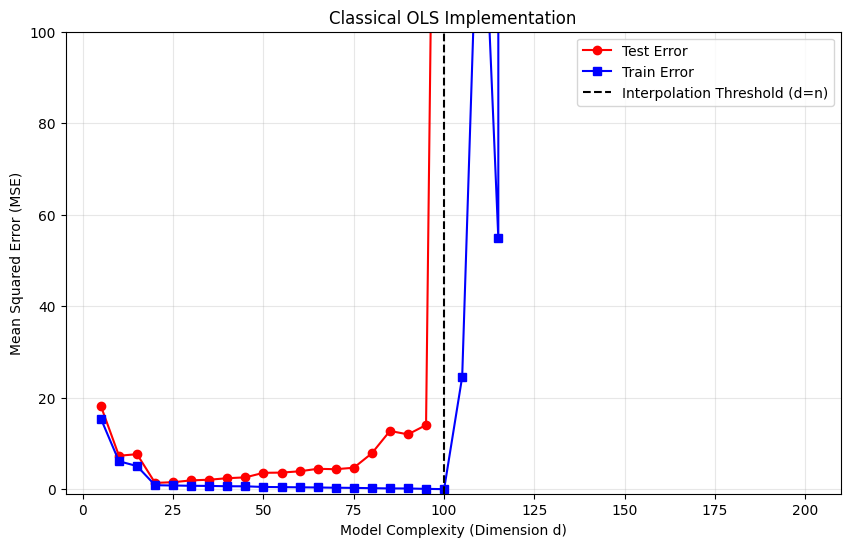

In [42]:
# Train of the model: least squares

def fit_ols_classical(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

n = 100
d_values = range(5, 205, 5)

X_tr_full, y_tr, X_te_full, y_te = generate_synthetic_dataset(n, 205, seed=30)

train_errors = []
test_errors = []

for d in d_values:
    X_tr = X_tr_full[:, :d]
    X_te = X_te_full[:, :d]
    
    #matrix_to_invert = X_tr.T @ X_tr
    #eigenvalues = np.linalg.eigvalsh(matrix_to_invert)
    #min_eig = np.min(np.abs(eigenvalues))
    
    w_hat = fit_ols_classical(X_tr, y_tr)
    
    #print(f"d = {d:3d} | Min Eigenvalue: {min_eig:.2e} | Max Weight: {np.max(np.abs(w_hat)):.2e}")    
    y_pred_tr = X_tr @ w_hat
    y_pred_te = X_te @ w_hat
    
    train_errors.append(compute_mse(y_tr, y_pred_tr))
    test_errors.append(compute_mse(y_te, y_pred_te))

plt.figure(figsize=(10, 6))
plt.plot(d_values, test_errors, label='Test Error', color='red', marker='o')
plt.plot(d_values, train_errors, label='Train Error', color='blue', marker='s')
plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(-1, 100)
plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Classical OLS Implementation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
def fit_ridge_classical(X, y, alpha=0.1):
    d = X.shape[1]
    return np.linalg.inv(X.T @ X + alpha * np.eye(d)) @ X.T @ y

In [44]:
ridge_train_errors = []
ridge_test_errors = []
train_errors = []
test_errors = []

for d in d_values:
    X_tr = X_tr_full[:, :d]
    X_te = X_te_full[:, :d]
    
    
    w_hat = fit_ols_classical(X_tr, y_tr)
    
    y_pred_tr = X_tr @ w_hat
    y_pred_te = X_te @ w_hat
    
    train_errors.append(compute_mse(y_tr, y_pred_tr))
    test_errors.append(compute_mse(y_te, y_pred_te))
    
    w_hat_ridge = fit_ridge_classical(X_tr, y_tr, alpha=0.1)
    
    y_pred_tr_ridge = X_tr @ w_hat_ridge
    y_pred_te_ridge = X_te @ w_hat_ridge
    
    ridge_train_errors.append(compute_mse(y_tr, y_pred_tr_ridge))
    ridge_test_errors.append(compute_mse(y_te, y_pred_te_ridge))

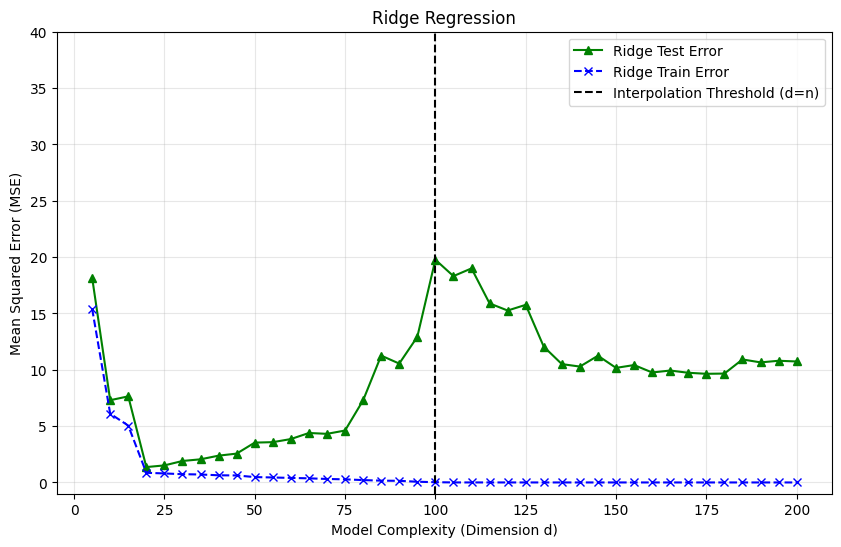

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(d_values, ridge_test_errors, label='Ridge Test Error', color='green', marker='^')
plt.plot(d_values, ridge_train_errors, label='Ridge Train Error', color='blue', marker='x', linestyle='--')

plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(-1, 40)
plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Ridge Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

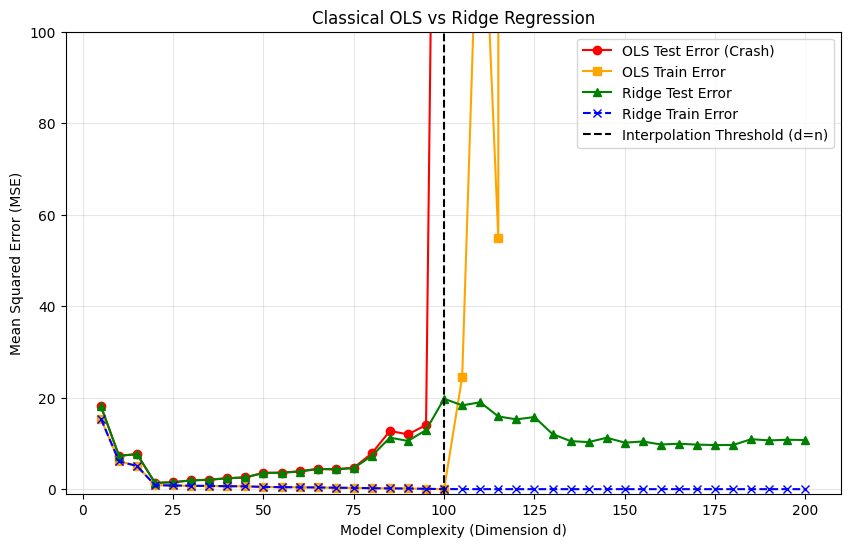

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(d_values, test_errors, label='OLS Test Error (Crash)', color='red', marker='o')
plt.plot(d_values, train_errors, label='OLS Train Error', color='orange', marker='s')

plt.plot(d_values, ridge_test_errors, label='Ridge Test Error', color='green', marker='^')
plt.plot(d_values, ridge_train_errors, label='Ridge Train Error', color='blue', marker='x', linestyle='--')

plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(-1, 100)
plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Classical OLS vs Ridge Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

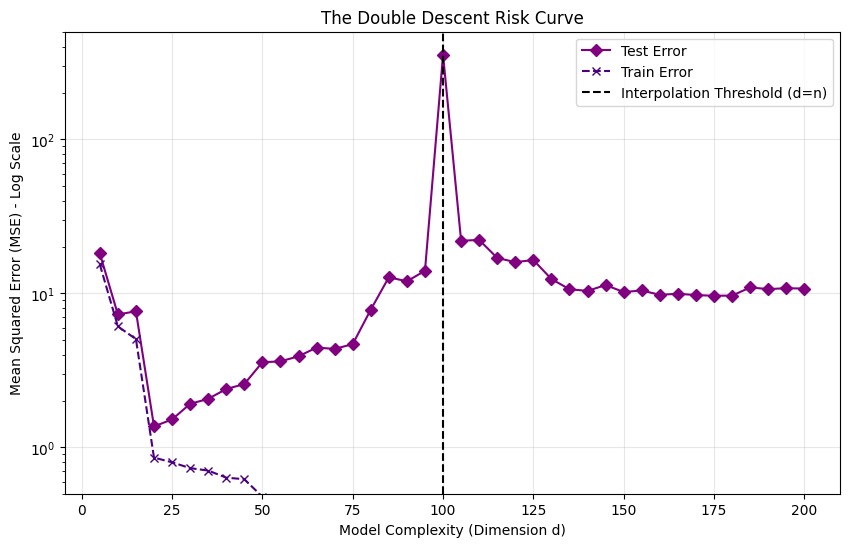

In [ ]:
def fit_double_descent_scratch(X, y):
    n, d = X.shape
    
    if d <= n:
        return np.linalg.inv(X.T @ X) @ X.T @ y
    else:
        return X.T @ np.linalg.inv(X @ X.T) @ y

train_errors = []
test_errors = []
dd_train_errors = []
dd_test_errors = []

ols_norms = []
dd_norms = []

for d in d_values:
    X_tr = X_tr_full[:, :d]
    X_te = X_te_full[:, :d]
    
    w_hat = fit_ols_classical(X_tr, y_tr)
    train_errors.append(compute_mse(y_tr, X_tr @ w_hat))
    test_errors.append(compute_mse(y_te, X_te @ w_hat))
    ols_norms.append(np.linalg.norm(w_hat))
    
    w_hat_dd = fit_double_descent_scratch(X_tr, y_tr)
    dd_train_errors.append(compute_mse(y_tr, X_tr @ w_hat_dd))
    dd_test_errors.append(compute_mse(y_te, X_te @ w_hat_dd))
    dd_norms.append(np.linalg.norm(w_hat_dd))


plt.figure(figsize=(10, 6))
plt.yscale('log')

plt.plot(d_values, dd_test_errors, label='Test Error', color='purple', marker='D')
plt.plot(d_values, dd_train_errors, label='Train Error', color='indigo', marker='x', linestyle='--')

plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(0.5, 500) 

plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('Mean Squared Error (MSE) - Log Scale')
plt.title('The Double Descent Risk Curve')
plt.legend()

plt.grid(True, alpha=0.3) 
plt.show()

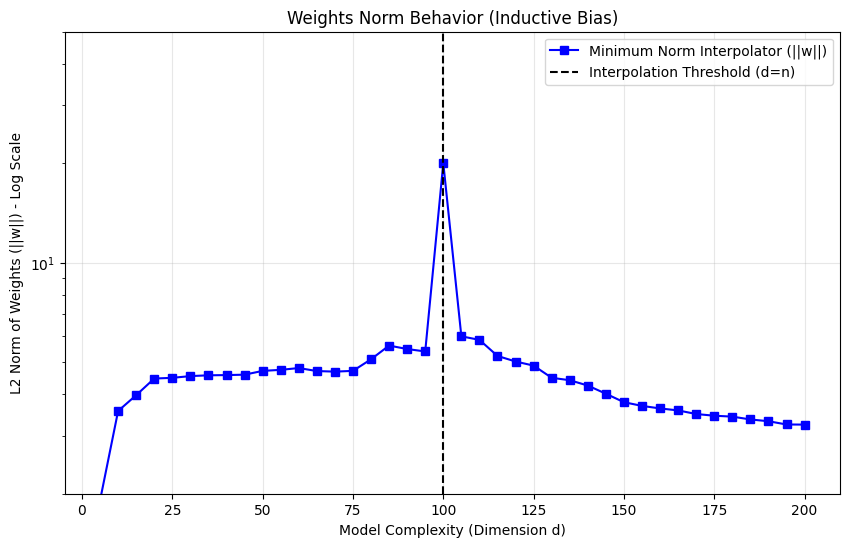

In [48]:
plt.figure(figsize=(10, 6))
plt.yscale('log')

plt.plot(d_values, dd_norms, label='Minimum Norm Interpolator (||w||)', color='blue', marker='s')


plt.axvline(x=n, color='black', linestyle='--', label='Interpolation Threshold (d=n)')

plt.ylim(2, 50) 

plt.xlabel('Model Complexity (Dimension d)')
plt.ylabel('L2 Norm of Weights (||w||) - Log Scale')
plt.title('Weights Norm Behavior (Inductive Bias)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()